# Proyecto 05: Visión artificial para detección de fallas mecánicas

## Contexto del proyecto

Este proyecto aplica técnicas de visión artificial y redes neuronales convolucionales para clasificar imágenes de componentes mecánicos utilizados en mantenimiento industrial.

El objetivo es construir un modelo de Machine Learning capaz de identificar visualmente piezas en buen estado y piezas con posibles fallas, utilizando imágenes de pistones clasificadas en distintas categorías.

Este tipo de solución puede apoyar procesos de diagnóstico, mantenimiento preventivo, control de calidad y reducción de tiempos de inspección en entornos industriales.

## Objetivo general

Desarrollar un modelo de clasificación de imágenes mediante una red neuronal convolucional CNN, utilizando TensorFlow y Keras, para identificar fallas visuales en componentes mecánicos.

## Categorías del modelo

- Defected1: componente con falla tipo 1.
- Defected2: componente con falla tipo 2.
- Normal: componente en buen estado.

## Herramientas utilizadas

- Python
- TensorFlow
- Keras
- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- Pillow

## Enfoque del proyecto

Este notebook reconstruye y mejora una implementación inicial desarrollada en el contexto de inteligencia artificial aplicada al control industrial, ordenando el flujo de trabajo para uso en portafolio profesional.

In [3]:
import sys
import tensorflow as tf

print("Python ejecutándose desde:")
print(sys.executable)

print("\nVersión TensorFlow:")
print(tf.__version__)

Python ejecutándose desde:
C:\Users\amena\anaconda3\envs\vision_cnn\python.exe

Versión TensorFlow:
2.21.0


In [1]:
# Importación de librerías principales

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# Definición de rutas del proyecto

PROJECT_ROOT = Path.cwd().parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATASET_PATH = DATA_RAW / "dataset"

OUTPUTS = PROJECT_ROOT / "outputs"
GRAFICOS_PATH = OUTPUTS / "graficos"
METRICAS_PATH = OUTPUTS / "metricas"
MODELOS_PATH = OUTPUTS / "modelos"

print("Ruta raíz del proyecto:", PROJECT_ROOT)
print("Ruta del dataset:", DATASET_PATH)

print("\n¿Existe la carpeta del dataset?", DATASET_PATH.exists())

Ruta raíz del proyecto: C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Science\proyecto_05_vision_artificial_fallas_mecanicas
Ruta del dataset: C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Science\proyecto_05_vision_artificial_fallas_mecanicas\data\raw\dataset

¿Existe la carpeta del dataset? True


In [4]:
# Revisión del contenido del dataset

class_folders = sorted([folder for folder in DATASET_PATH.iterdir() if folder.is_dir()])

print("Carpetas detectadas en el dataset:\n")

total_images = 0

for folder in class_folders:
    image_files = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tiff", "*.webp"]:
        image_files.extend(list(folder.glob(ext)))
    
    total_images += len(image_files)
    print(f"- {folder.name}: {len(image_files)} imágenes")

print("\nTotal de imágenes detectadas:", total_images)

Carpetas detectadas en el dataset:

- Defected1: 88 imágenes
- Defected2: 98 imágenes
- Normal: 99 imágenes

Total de imágenes detectadas: 285


## 2. Carga y preparación del dataset

En esta sección se construye una tabla base con la ruta de cada imagen y su categoría correspondiente.

El dataset está organizado en carpetas, donde cada carpeta representa una clase del problema:

- Defected1
- Defected2
- Normal

A partir de esta estructura se generará un conjunto de datos ordenado para entrenamiento, validación y prueba del modelo CNN.

In [5]:
# Crear una tabla con rutas de imágenes y etiquetas

valid_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tiff", "*.webp"]

records = []

for class_folder in sorted(DATASET_PATH.iterdir()):
    if class_folder.is_dir():
        class_name = class_folder.name
        
        for ext in valid_extensions:
            for image_path in class_folder.glob(ext):
                records.append({
                    "path": str(image_path),
                    "label": class_name
                })

df_images = pd.DataFrame(records)

print("Total de imágenes cargadas:", len(df_images))
print("\nDistribución por clase:")
display(df_images["label"].value_counts().reset_index().rename(
    columns={"index": "clase", "label": "cantidad"}
))

df_images.head()

Total de imágenes cargadas: 285

Distribución por clase:


,cantidad,count
0,Normal,99
1,Defected2,98
2,Defected1,88


,path,label
0,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Defected1
1,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Defected1
2,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Defected1
3,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Defected1
4,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Defected1


In [6]:
# Codificación numérica de clases

class_names = sorted(df_images["label"].unique())
class_to_index = {class_name: index for index, class_name in enumerate(class_names)}
index_to_class = {index: class_name for class_name, index in class_to_index.items()}

df_images["label_id"] = df_images["label"].map(class_to_index)

print("Clases detectadas:")
for class_name, index in class_to_index.items():
    print(f"{index}: {class_name}")

df_images.head()

Clases detectadas:
0: Defected1
1: Defected2
2: Normal


,path,label,label_id
0,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Defected1,0
1,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Defected1,0
2,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Defected1,0
3,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Defected1,0
4,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Defected1,0


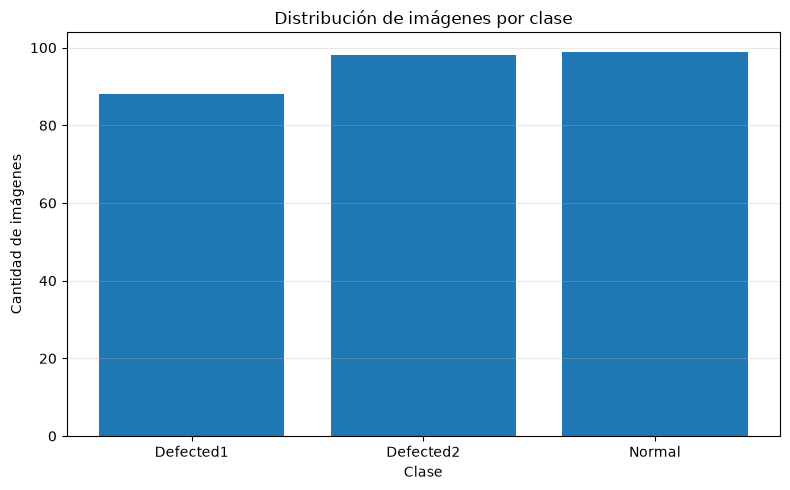

In [7]:
# Visualización de la distribución de imágenes por clase

class_counts = df_images["label"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Distribución de imágenes por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(GRAFICOS_PATH / "distribucion_imagenes_por_clase.png", dpi=300)
plt.show()

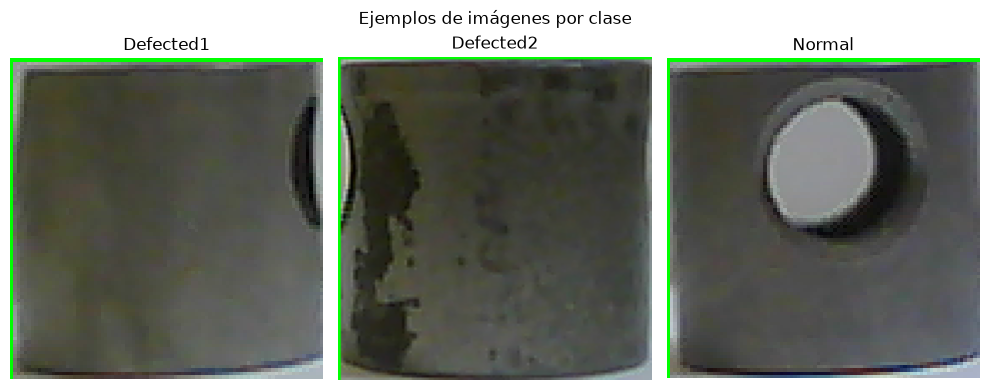

In [8]:
# Mostrar una imagen de ejemplo por cada clase

plt.figure(figsize=(10, 4))

for i, class_name in enumerate(class_names):
    sample_path = df_images[df_images["label"] == class_name]["path"].iloc[0]
    img = Image.open(sample_path)
    
    plt.subplot(1, len(class_names), i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Ejemplos de imágenes por clase")
plt.tight_layout()

plt.savefig(GRAFICOS_PATH / "ejemplos_imagenes_por_clase.png", dpi=300)
plt.show()

## 3. División del dataset

El dataset se dividirá en tres conjuntos:

- Entrenamiento: utilizado para que el modelo aprenda.
- Validación: utilizado para monitorear el desempeño durante el entrenamiento.
- Prueba: utilizado para evaluar el modelo final con imágenes no vistas.

Se utilizará una división estratificada para mantener una proporción similar de clases en cada conjunto.

In [9]:
# División estratificada del dataset

RANDOM_STATE = 42

train_df, temp_df = train_test_split(
    df_images,
    test_size=0.30,
    stratify=df_images["label_id"],
    random_state=RANDOM_STATE
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=RANDOM_STATE
)

print("Tamaño entrenamiento:", len(train_df))
print("Tamaño validación:", len(valid_df))
print("Tamaño prueba:", len(test_df))

print("\nDistribución entrenamiento:")
display(train_df["label"].value_counts().reset_index())

print("\nDistribución validación:")
display(valid_df["label"].value_counts().reset_index())

print("\nDistribución prueba:")
display(test_df["label"].value_counts().reset_index())

Tamaño entrenamiento: 199
Tamaño validación: 43
Tamaño prueba: 43

Distribución entrenamiento:


,label,count
0,Normal,69
1,Defected2,68
2,Defected1,62



Distribución validación:


,label,count
0,Defected2,15
1,Normal,15
2,Defected1,13



Distribución prueba:


,label,count
0,Normal,15
1,Defected2,15
2,Defected1,13


In [10]:
# Parámetros para el procesamiento de imágenes

IMG_SIZE = (96, 96)
BATCH_SIZE = 16
NUM_CLASSES = len(class_names)

print("Tamaño de imagen:", IMG_SIZE)
print("Tamaño de batch:", BATCH_SIZE)
print("Número de clases:", NUM_CLASSES)
print("Clases:", class_names)

Tamaño de imagen: (96, 96)
Tamaño de batch: 16
Número de clases: 3
Clases: ['Defected1', 'Defected2', 'Normal']


In [11]:
# Función para cargar y preprocesar imágenes

AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def create_tf_dataset(dataframe, shuffle=False):
    paths = dataframe["path"].values
    labels = dataframe["label_id"].values
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=RANDOM_STATE)
    
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    
    return dataset


train_ds = create_tf_dataset(train_df, shuffle=True)
valid_ds = create_tf_dataset(valid_df, shuffle=False)
test_ds = create_tf_dataset(test_df, shuffle=False)

print("Datasets creados correctamente.")

Datasets creados correctamente.


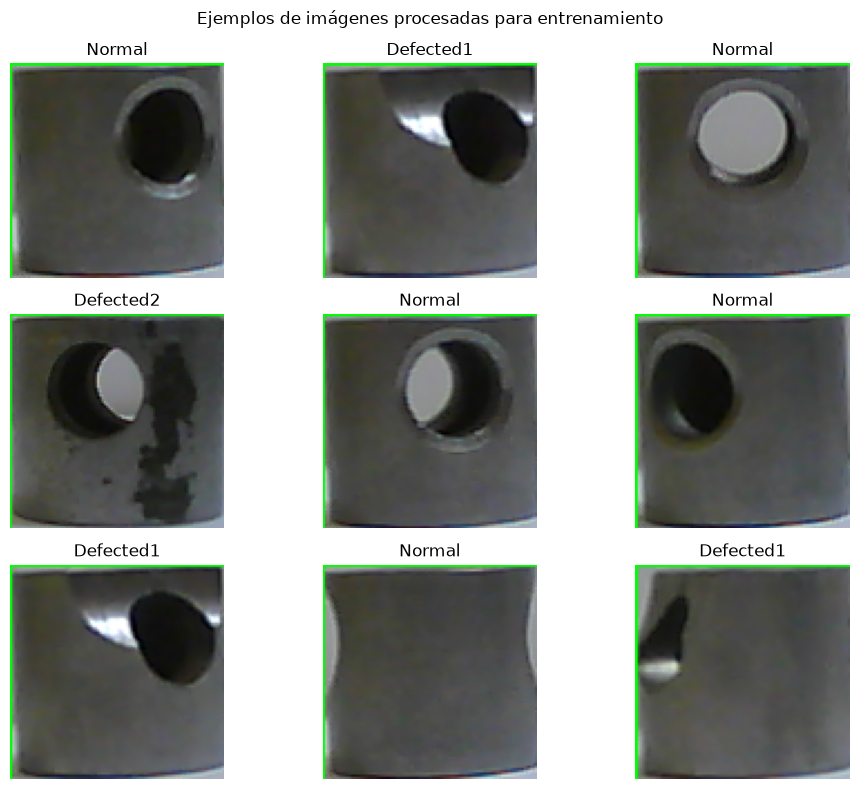

In [12]:
# Visualizar un batch de imágenes procesadas

plt.figure(figsize=(10, 8))

for images_batch, labels_batch in train_ds.take(1):
    for i in range(min(9, len(images_batch))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images_batch[i])
        label_id = int(labels_batch[i].numpy())
        plt.title(index_to_class[label_id])
        plt.axis("off")

plt.suptitle("Ejemplos de imágenes procesadas para entrenamiento")
plt.tight_layout()

plt.savefig(GRAFICOS_PATH / "batch_imagenes_entrenamiento.png", dpi=300)
plt.show()

## 4. Construcción del modelo CNN

Se construirá una red neuronal convolucional para clasificar imágenes de componentes mecánicos en tres categorías:

- Defected1
- Defected2
- Normal

Debido a que el dataset es pequeño, se incorpora una etapa de aumento de datos para mejorar la capacidad de generalización del modelo.

In [13]:
# Aumento de datos para mejorar la generalización del modelo

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
], name="data_augmentation")

print("Capa de aumento de datos creada correctamente.")

Capa de aumento de datos creada correctamente.


In [14]:
# Construcción del modelo CNN

model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    data_augmentation,
    
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 96, 96, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 48, 48, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       2,359,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,453,059 (9.36 MB)

 Trainable params: 2,453,059 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compilación del modelo

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo compilado correctamente.")

Modelo compilado correctamente.


In [16]:
# Entrenamiento del modelo

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

EPOCHS = 50

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.3216 - loss: 1.1770 - val_accuracy: 0.3488 - val_loss: 1.0939
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.3568 - loss: 1.0924 - val_accuracy: 0.3953 - val_loss: 1.0802
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - accuracy: 0.3970 - loss: 1.0819 - val_accuracy: 0.4884 - val_loss: 1.0408
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.4171 - loss: 1.0816 - val_accuracy: 0.3488 - val_loss: 1.0535
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.4573 - loss: 1.0158 - val_accuracy: 0.5581 - val_loss: 0.9107
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.5427 - loss: 0.9064 - val_accuracy: 0.6047 - val_loss: 0.8071
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.6131 - loss: 0.7605 - val_accuracy: 0.8372 - val_loss: 0.4170
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.6834 - loss: 0.6838 - val_accuracy: 0.

In [17]:
# Guardar el modelo entrenado

model_path = MODELOS_PATH / "modelo_cnn_fallas_mecanicas.keras"
model.save(model_path)

print("Modelo guardado en:")
print(model_path)

Modelo guardado en:
C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Science\proyecto_05_vision_artificial_fallas_mecanicas\outputs\modelos\modelo_cnn_fallas_mecanicas.keras


In [18]:
# Guardar historial de entrenamiento en DataFrame

history_df = pd.DataFrame(history.history)
history_df.to_csv(METRICAS_PATH / "historial_entrenamiento_cnn.csv", index=False)

history_df.tail()

,accuracy,loss,val_accuracy,val_loss
22,0.884422,0.284167,0.976744,0.077801
23,0.914573,0.222488,0.930233,0.208313
24,0.919598,0.180297,0.953488,0.074517
25,0.914573,0.190353,0.930233,0.094153
26,0.944724,0.155681,0.930233,0.090509


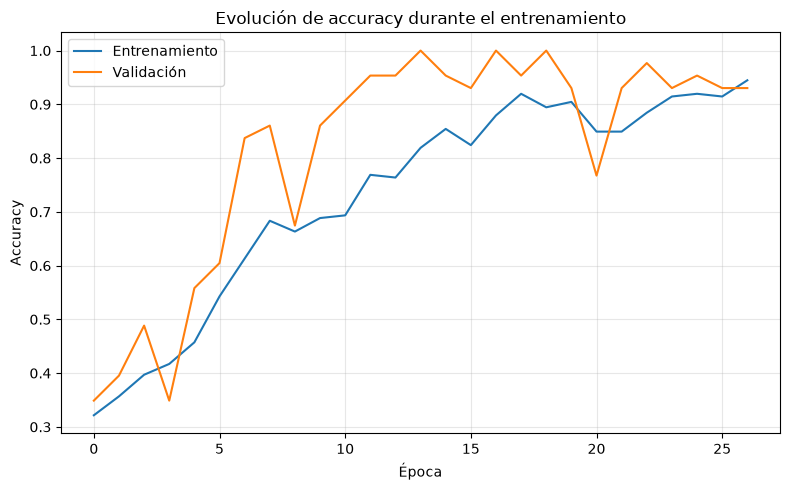

In [19]:
# Gráfico de accuracy entrenamiento vs validación

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Entrenamiento")
plt.plot(history_df["val_accuracy"], label="Validación")
plt.title("Evolución de accuracy durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(GRAFICOS_PATH / "accuracy_entrenamiento_validacion.png", dpi=300)
plt.show()

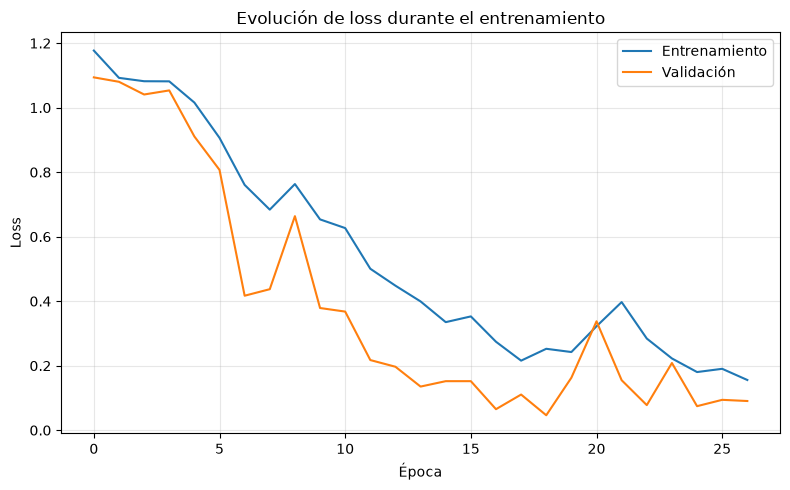

In [20]:
# Gráfico de loss entrenamiento vs validación

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Entrenamiento")
plt.plot(history_df["val_loss"], label="Validación")
plt.title("Evolución de loss durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(GRAFICOS_PATH / "loss_entrenamiento_validacion.png", dpi=300)
plt.show()

In [21]:
# Evaluación final sobre conjunto de prueba

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0956 
Test loss: 0.0956
Test accuracy: 1.0


In [22]:
# Predicciones sobre conjunto de prueba

y_true = np.concatenate([labels.numpy() for images, labels in test_ds], axis=0)

y_pred_prob = model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Cantidad de predicciones:", len(y_pred))
print("Cantidad de etiquetas reales:", len(y_true))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Cantidad de predicciones: 43
Cantidad de etiquetas reales: 43


In [23]:
# Reporte de clasificación

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(METRICAS_PATH / "reporte_clasificacion_cnn.csv")

display(report_df)

,precision,recall,f1-score,support
Defected1,1.0,1.0,1.0,13.0
Defected2,1.0,1.0,1.0,15.0
Normal,1.0,1.0,1.0,15.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,43.0
weighted avg,1.0,1.0,1.0,43.0


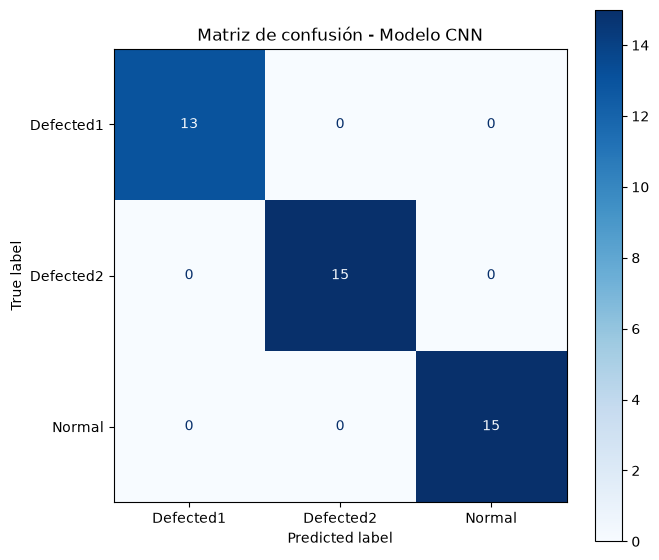

In [24]:
# Matriz de confusión

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Matriz de confusión - Modelo CNN")
plt.tight_layout()

plt.savefig(GRAFICOS_PATH / "matriz_confusion_cnn.png", dpi=300)
plt.show()

In [25]:
# Guardar resumen de métricas principales

metrics_summary = pd.DataFrame({
    "modelo": ["CNN visión artificial fallas mecánicas"],
    "test_loss": [test_loss],
    "test_accuracy": [test_accuracy],
    "cantidad_imagenes": [len(df_images)],
    "clases": [", ".join(class_names)]
})

metrics_summary.to_csv(METRICAS_PATH / "metricas_resumen_modelo_cnn.csv", index=False)

display(metrics_summary)

,modelo,test_loss,test_accuracy,cantidad_imagenes,clases
0,CNN visión artificial fallas mecánicas,0.095611,1.0,285,"Defected1, Defected2, Normal"


In [26]:
# Crear tabla con resultados de predicción

test_results = test_df.copy().reset_index(drop=True)
test_results["real_id"] = y_true
test_results["pred_id"] = y_pred
test_results["real_label"] = test_results["real_id"].map(index_to_class)
test_results["pred_label"] = test_results["pred_id"].map(index_to_class)
test_results["correcto"] = test_results["real_id"] == test_results["pred_id"]

test_results.to_csv(METRICAS_PATH / "predicciones_conjunto_prueba.csv", index=False)

display(test_results.head())
print("Predicciones correctas:", test_results["correcto"].sum())
print("Total predicciones:", len(test_results))

,path,label,label_id,real_id,pred_id,real_label,pred_label,correcto
0,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Defected1,0,0,0,Defected1,Defected1,True
1,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Normal,2,2,2,Normal,Normal,True
2,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Normal,2,2,2,Normal,Normal,True
3,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Normal,2,2,2,Normal,Normal,True
4,C:\Users\amena\DESAFIOLATAM\Portafolio_Data_Sc...,Defected2,1,1,1,Defected2,Defected2,True


Predicciones correctas: 43
Total predicciones: 43


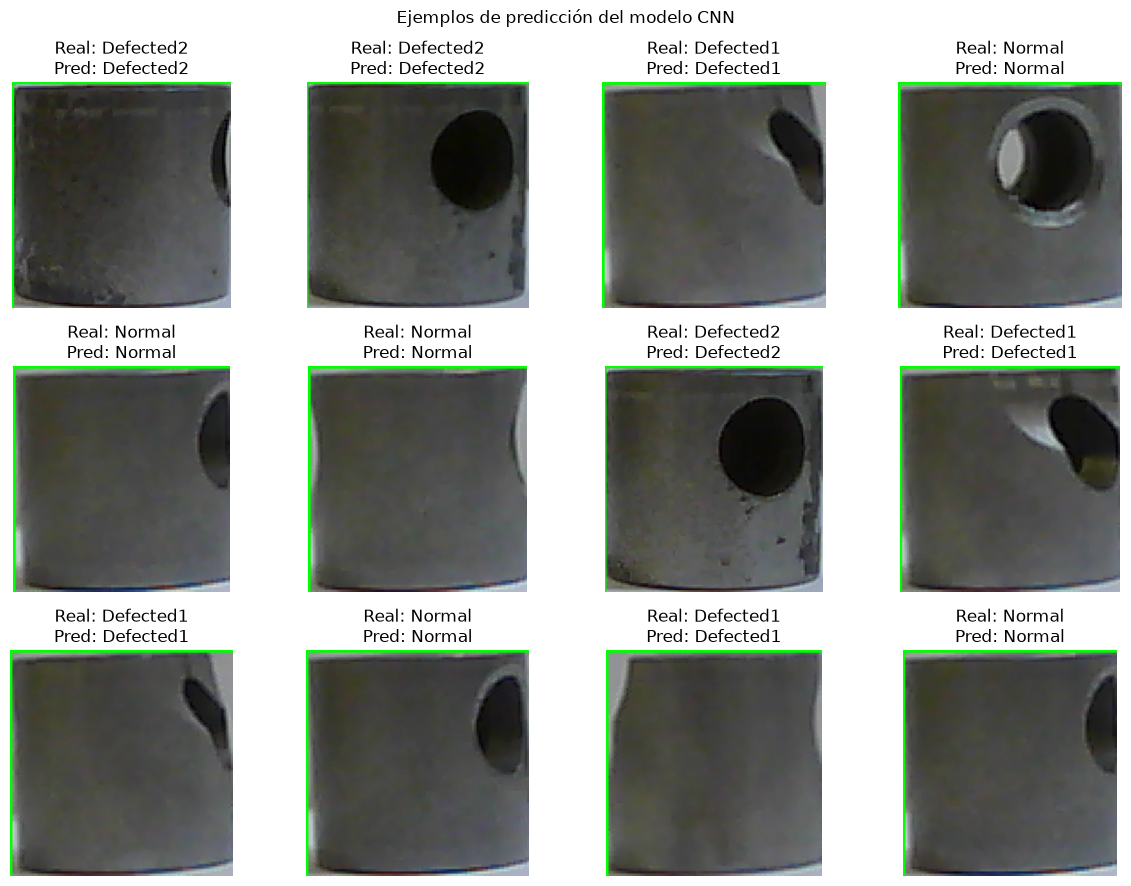

In [27]:
# Visualizar ejemplos de predicción del conjunto de prueba

sample_results = test_results.sample(
    n=min(12, len(test_results)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(12, 9))

for i, row in enumerate(sample_results.itertuples()):
    img = Image.open(row.path)
    
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Real: {row.real_label}\nPred: {row.pred_label}")
    plt.axis("off")

plt.suptitle("Ejemplos de predicción del modelo CNN")
plt.tight_layout()

plt.savefig(GRAFICOS_PATH / "ejemplos_prediccion_modelo_cnn.png", dpi=300)
plt.show()

## 7. Conclusiones

El modelo CNN desarrollado logró clasificar imágenes de componentes mecánicos en tres categorías: Defected1, Defected2 y Normal.

A diferencia de la implementación inicial, este notebook organiza el flujo completo del proyecto de forma reproducible: carga del dataset, preparación de rutas, división estratificada de datos, preprocesamiento de imágenes, entrenamiento del modelo, evaluación final y exportación de métricas.

El modelo alcanzó un desempeño alto sobre el conjunto de prueba utilizado, con una accuracy final de 1.0. Este resultado indica que la red neuronal fue capaz de reconocer patrones visuales relevantes entre las clases del dataset.

Sin embargo, debido al tamaño reducido de la base de imágenes, este resultado debe interpretarse con cautela. Para una implementación industrial real, sería necesario validar el modelo con una mayor cantidad de imágenes, distintas condiciones de iluminación, ángulos de captura, niveles de desgaste, suciedad, sombras y variabilidad operacional.

Desde una perspectiva industrial, este tipo de solución puede apoyar procesos de mantenimiento, diagnóstico visual, control de calidad y reducción de tiempos de inspección en componentes mecánicos.

## 8. Próximos pasos

- Ampliar el dataset con imágenes reales capturadas en condiciones industriales.
- Incorporar nuevas clases de fallas mecánicas.
- Evaluar modelos preentrenados mediante Transfer Learning.
- Comparar CNN simple vs modelos como MobileNetV2, ResNet o EfficientNet.
- Implementar una interfaz simple para cargar una imagen y obtener una predicción.
- Integrar el modelo con una aplicación de inspección o control de mantenimiento.